In [1]:
import re
import nltk
import spacy
import string
import textstat
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from unidecode import unidecode as _unidecode
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

nltk.download('cmudict')
textstat.set_lang("pt")

[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\luan.barbosa\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


## Criando, Filtrando e Limpando a Base

In [2]:
nlp = spacy.load("pt_core_news_lg", disable=["ner", "parser"])

def normalize_unidecode(text: str) -> str:
    return _unidecode(text)

def base_clean_pt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text.strip()) # remove breaks and normalize spaces
    text = re.sub(r'<[^>]+>', '', text) # remove HTML, URLs, and emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = normalize_unidecode(text) # normalize accents
    text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text) # remove alphanumeric tokens of type Q12, A1, C3
    text = re.sub(r'[^\w\s\-\']', ' ', text) # remove loose punctuation (keep hyphens and apostrophes within words if they exist)
    text = re.sub(r'\s+', ' ', text).strip() # normalize spaces again
    return text.lower()

def spacy_process(texts, lemmatize = False, remove_stopwords = False, batch_size=512):
    cleaned = (base_clean_pt(t) for t in texts)
    results = []

    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for tok in doc:
            if tok.is_punct or tok.is_space or tok.like_num or len(tok.text) <= 2:
                continue
            if remove_stopwords and tok.is_stop:
                continue

            token = tok.lemma_ if lemmatize else tok.text
            tokens.append(token.lower())

        results.append(" ".join(tokens))

    return results

def data_preprocessing(df, column_name):
    df["UNCLEAN_TEXT"] = (
        df[column_name]
        .fillna("")
        .astype(str)
    )

    df["CLEAN_TEXT"] = spacy_process(
        df["UNCLEAN_TEXT"],
        lemmatize=False,
        remove_stopwords=False
    )

    return df

In [3]:
df_1 = pd.read_csv("../data/goemotions_1_pt.csv")
df_2 = pd.read_csv("../data/goemotions_2_pt.csv")
df_3 = pd.read_csv("../data/goemotions_3_pt.csv")

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['author', 'subreddit', 'link_id', 'parent_id', 'created_utc'], inplace=True)

print(df.shape)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

for c in emotion_cols:
    df[c] = (
        df.groupby('id')[c]
        .transform('sum')
        .ge(2)
        .astype(int)
    )

df['label_sum'] = df[emotion_cols].sum(axis=1)
df = df[df['label_sum'] > 0]

df = (
    df
    .groupby('id', as_index=False)
    .agg(
        {
            **{c: 'max' for c in emotion_cols},
            'text': 'first',
            'texto': 'first'
        }
    )
)

print(df.shape)  # ~54k

conflicts = (
    df
    .groupby('id')[emotion_cols]
    .nunique()
    .max(axis=1)
)

print((conflicts > 1).sum()) # 0

df = data_preprocessing(df, 'texto')

n_nan = df['CLEAN_TEXT'].isna().sum()

n_empty = (df['CLEAN_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['CLEAN_TEXT'])
df = df[df['CLEAN_TEXT'].str.strip() != '']

print(df.shape)
print(df.columns)
df.head(1)

(211225, 33)
(54263, 31)
0
Textos NaN: 0
Textos vazios ou em branco: 29
Total problemáticos: 29
(54234, 33)
Index(['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral',
       'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT'],
      dtype='object')


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,realization,relief,remorse,sadness,surprise,neutral,text,texto,UNCLEAN_TEXT,CLEAN_TEXT
0,eczazk6,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,Fast as [NAME] will carry me. Seriously uptown...,Tão rápido quanto [NOME] me carregará. Seriame...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...


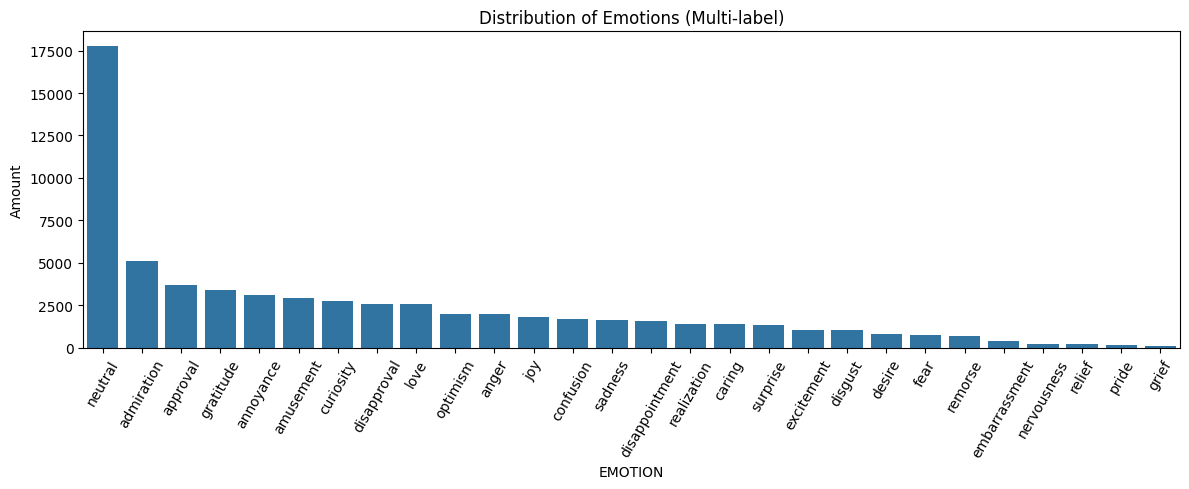

In [4]:
emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=60)
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

## Engenharia de Features

In [5]:
nlp = spacy.load("pt_core_news_lg", disable=["ner"])

AUXILIARY_VERBS_PT = {
    "ser", "estar", "ter", "haver", "ir"
}

def get_textstat_features(texts):
    features = []
    for x in texts:
        n_sent = max(textstat.sentence_count(x), 1)
        n_words = max(textstat.lexicon_count(x), 1)

        features.append([
            textstat.letter_count(x),
            n_sent,
            textstat.avg_letter_per_word(x),
            n_words / n_sent,
            textstat.avg_syllables_per_word(x),
            textstat.reading_time(x),
        ])
    return np.array(features)

def mean_punctuation_per_word(texts):
    punct = set(string.punctuation)
    results = []

    for txt in texts:
        words = txt.split()
        n_words = len(words)

        if n_words == 0:
            results.append([0.0, 0.0, 0.0])
            continue

        total_punct = sum(1 for ch in txt if ch in punct)
        exclam = txt.count("!")
        quest = txt.count("?")
        
        results.append([
            total_punct / n_words,
            exclam / n_words,
            quest / n_words
        ])
    return np.array(results)

def mean_verbs_per_word(texts):
    feats = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "lemmatizer", "parser"]):
        words = [t for t in doc if t.is_alpha]
        if len(words) == 0:
            feats.append(0.0)
            continue
        verb_count = sum(1 for t in words if t.pos_ == "VERB")
        feats.append(verb_count / len(words))
    return np.array(feats).reshape(-1, 1)

def mean_auxiliaries_per_word(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "parser"]):
        tokens = [tok for tok in doc if tok.is_alpha]
        if len(tokens) == 0:
            results.append(0.0)
            continue

        aux_count = sum(1 for tok in tokens if tok.lemma_.lower() in AUXILIARY_VERBS_PT)
        results.append(aux_count / len(tokens))
    return results

def mean_auxiliaries_per_sentence(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner"]):
        n_sent = len(list(doc.sents))
        if n_sent == 0:
            results.append(0.0)
            continue

        tokens = [tok for tok in doc if tok.is_alpha]

        aux_count = sum(
            1 for tok in tokens
            if tok.lemma_.lower() in AUXILIARY_VERBS_PT
        )

        results.append(aux_count / n_sent)
    return np.array(results)

def flesch_portuguese(texts):
    scores = []
    for t in texts:
        text = str(t).strip()

        num_sent = textstat.sentence_count(text)
        num_words = len(text.split())
        num_syll = textstat.syllable_count(text)

        if num_sent == 0 or num_words == 0:
            scores.append(0.0)
            continue

        flesch_pt = 226 - 1.04 * (num_words / num_sent) - 72 * (num_syll / num_words)
        scores.append(flesch_pt)

    return scores

def uppercase_percentage(texts):
    results = []

    for txt in texts:
        letters = [ch for ch in txt if ch.isalpha()]
        if len(letters) == 0:
            results.append(0.0)
            continue

        upper = sum(1 for ch in letters if ch.isupper())
        results.append(upper / len(letters))

    return np.array(results).reshape(-1, 1)

def mean_unique_word_length(texts):
    results = []

    for txt in texts:
        words = [w.lower() for w in txt.split() if w.isalpha()]
        unique_words = set(words)

        if len(unique_words) == 0:
            results.append(0.0)
            continue

        mean_len = np.mean([len(w) for w in unique_words])
        results.append(mean_len)

    return np.array(results).reshape(-1, 1)

def mean_char_repetition_per_word(texts):
    results = []
    pattern = re.compile(r"(.)\1{2,}")  # 3+ repetições

    for txt in texts:
        words = txt.split()
        if len(words) == 0:
            results.append(0.0)
            continue

        repeated_words = sum(
            1 for w in words if pattern.search(w.lower())
        )

        results.append(repeated_words / len(words))

    return np.array(results).reshape(-1, 1)

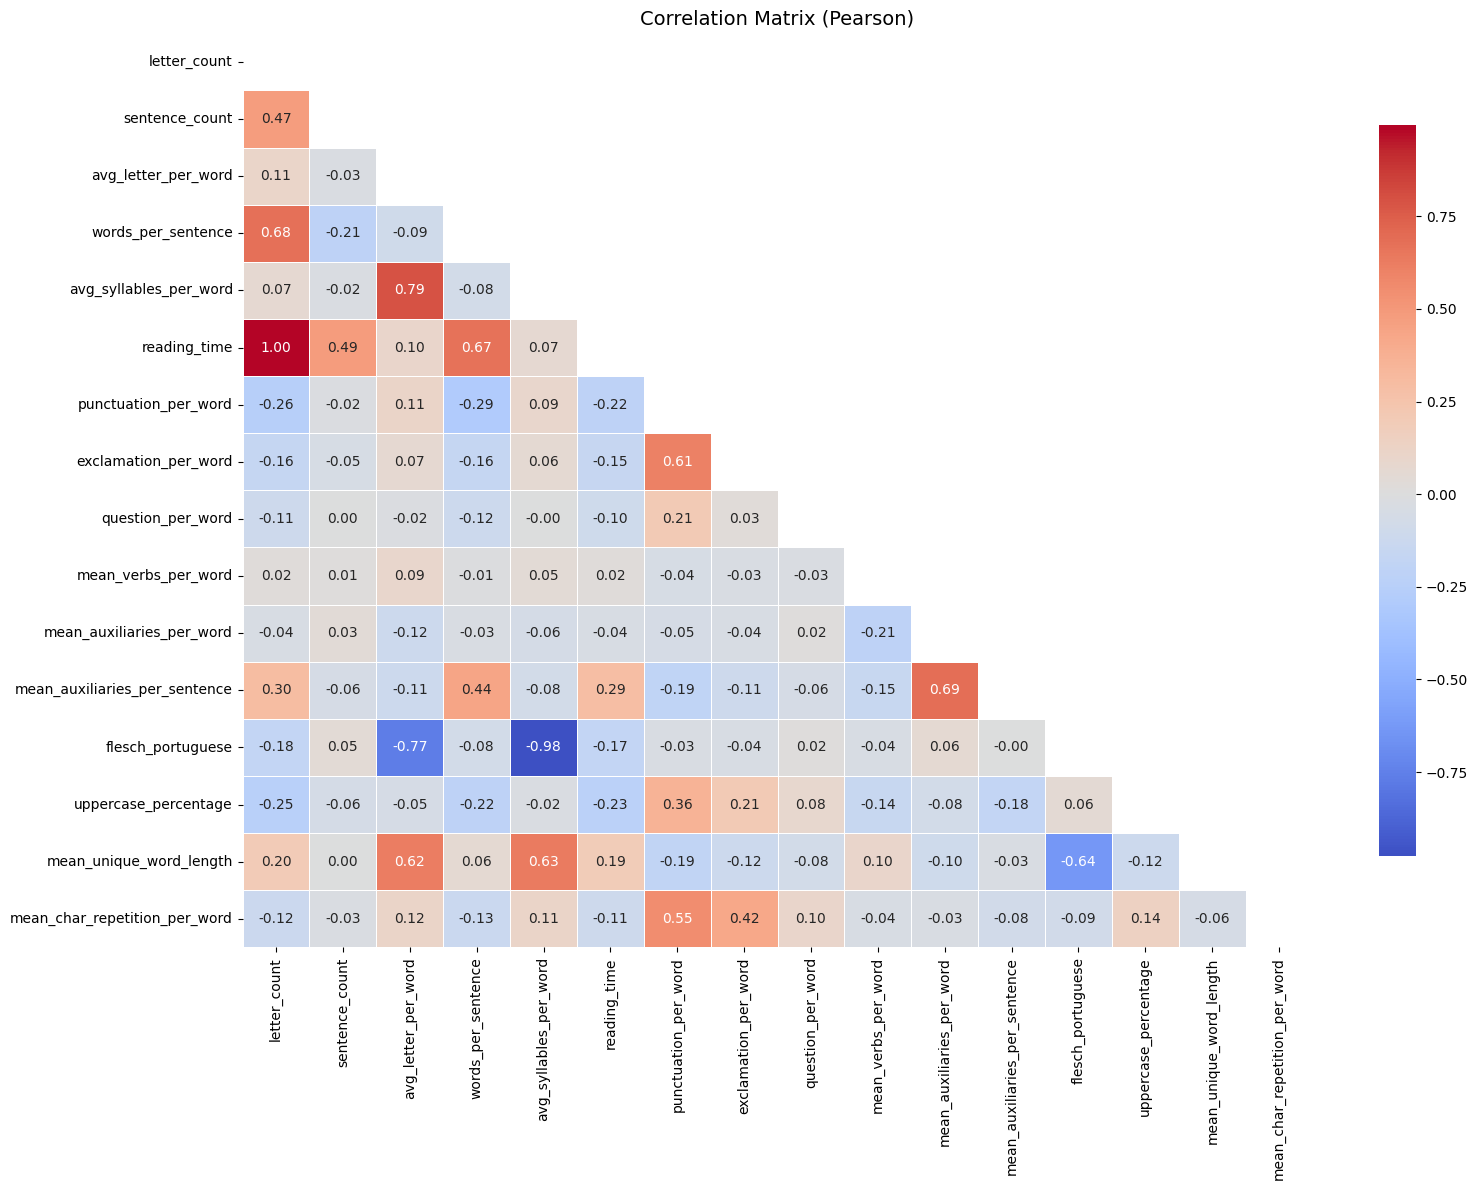

In [6]:
df['UNCLEAN_TEXT'] = (
    df['UNCLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

unclean_text_col = 'UNCLEAN_TEXT'

textstat_feats = get_textstat_features(df[unclean_text_col].tolist()) 

textstat_cols = [
    "letter_count",
    "sentence_count",
    "avg_letter_per_word",
    "words_per_sentence",
    "avg_syllables_per_word",
    "reading_time",
]

df_textstat = pd.DataFrame(textstat_feats, columns=textstat_cols) 
df = pd.concat([df.reset_index(drop=True), df_textstat.reset_index(drop=True)], axis=1)

punct_feats = mean_punctuation_per_word(df[unclean_text_col].tolist())

punct_cols = [
    "punctuation_per_word",
    "exclamation_per_word",
    "question_per_word"
]

df_punct = pd.DataFrame(punct_feats, columns=punct_cols)

df = pd.concat([df.reset_index(drop=True), df_punct], axis=1)

df["mean_verbs_per_word"] = mean_verbs_per_word(df[unclean_text_col])

df["mean_auxiliaries_per_word"] = mean_auxiliaries_per_word(df[unclean_text_col].tolist())
df["mean_auxiliaries_per_sentence"] = mean_auxiliaries_per_sentence(df[unclean_text_col].tolist())

df["flesch_portuguese"] = flesch_portuguese(df[unclean_text_col].tolist())

df["uppercase_percentage"] = uppercase_percentage(df[unclean_text_col].tolist())
df["mean_unique_word_length"] = mean_unique_word_length(df[unclean_text_col].tolist())
df["mean_char_repetition_per_word"] = mean_char_repetition_per_word(df[unclean_text_col].tolist())

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

num_cols = df.select_dtypes(include="number")
num_cols = [col for col in num_cols if col not in emotion_cols]
df_num = df[num_cols]
corr = df_num.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

## Divisão em Folds

In [7]:
y = df[emotion_cols]

output_dir = Path("../data/treated")
output_dir.mkdir(parents=True, exist_ok=True)

mskf = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# O split precisa de X, mas ele não é utilizado pela estratificação
X_dummy = np.zeros((len(df), 1))

for fold, (_, fold_idx) in enumerate(mskf.split(X_dummy, y), start=1):
    fold_dir = output_dir / f"fold_{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    fold_df = df.iloc[fold_idx].reset_index(drop=True)

    fold_df.to_parquet(fold_dir / "data.parquet", index=False)
    np.save(fold_dir / "idx.npy", fold_idx)

print("5 folds criados com sucesso.")

5 folds criados com sucesso.
